In [1]:
import sys
sys.path.insert(0, '/app')
%load_ext autoreload
%autoreload 2

%reload_ext autoreload
import numpy as np
import pandas as pd
from pathlib import Path

from strat.analysis import (
    ETF_LIST,
    DEFAULT_HORIZONS,
    compute_hourly_performance_ranking,
    compute_rolling_performance_ranking,
)

INPUT_FILE = Path("/data/bundle/test_etf_features_bundle.parquet")
OUTPUT_DIR = Path("/data/work/performance_ranking/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"ETF List: {ETF_LIST}")
print(f"Default Horizons (hours): {DEFAULT_HORIZONS}")

ETF List: ['QQQ', 'SPY', 'TLT', 'GLD', 'VWO']
Default Horizons (hours): [1, 2, 3, 4, 8, 12, 24, 48, 240, 480]


## Configuration

Set time horizons for analysis:

In [2]:
HORIZONS = [1, 2, 3, 4, 8, 12, 24, 48, 240, 480]
N_RANKS = 5

print("Horizons (hours):")
for h in HORIZONS:
    print(f"  {h}h = {h/24:.1f} days")

Horizons (hours):
  1h = 0.0 days
  2h = 0.1 days
  3h = 0.1 days
  4h = 0.2 days
  8h = 0.3 days
  12h = 0.5 days
  24h = 1.0 days
  48h = 2.0 days
  240h = 10.0 days
  480h = 20.0 days


## Step 1: Load Data

Load the ETF bundle:

In [ ]:
df = pd.read_parquet(INPUT_FILE)
print(f"Loaded: {df.shape}")
print(f"Index: {df.index.name}, dtype: {df.index.dtype}")

close_cols = [c for c in df.columns if 'S_close_f32' in c]
etfs_found = sorted(set(c.split('_')[0] for c in close_cols))
print(f"\nETFs with close prices: {etfs_found}")

In [9]:
df.columns

Index(['QQQ_S_open_f32', 'QQQ_S_high_f32', 'QQQ_S_low_f32', 'QQQ_S_close_f32',
       'QQQ_S_volume_f64', 'QQQ_S_open_time_i', 'QQQ_S_close_time_i',
       'QQQ_minute_diff', 'QQQ_gap_flag', 'QQQ_valid_row',
       ...
       'VWO_F_diff_rel_ema_2_F_mid_f32_2_f16',
       'VWO_F_diff_rel_ema_2_F_mid_f32_15_f16',
       'VWO_F_diff_rel_ema_2_F_mid_f32_60_f16',
       'VWO_F_diff_rel_ema_2_F_mid_f32_240_f16',
       'VWO_F_diff_rel_ema_2_F_mid_f32_500_f16',
       'VWO_F_diff_rel_ema_2_F_mid_f32_1440_f16', 'VWO_F_acc_dist_index_f64',
       'VWO_F_roc_14_F_mid_f32_f16', 'VWO_F_roc_60_F_mid_f32_f16',
       'VWO_F_roc_240_F_mid_f32_f16'],
      dtype='str', length=611)

## Step 2: Hourly Performance Ranking

Compute average performance rankings for each hour of the day (0-23):

In [4]:
hourly_ranking = compute_hourly_performance_ranking(
    p_df=df,
    p_etf_list=ETF_LIST,
    p_horizons=HORIZONS,
    p_n_ranks=N_RANKS,
)

print(f"Hourly ranking shape: {hourly_ranking.shape}")
print(f"\nIndex (hours): {list(hourly_ranking.index)}")

Hourly ranking shape: (24, 100)

Index (hours): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [5]:
bestperf_cols = [c for c in hourly_ranking.columns if c.startswith('bestperf_')]
print(f"Best performer columns: {len(bestperf_cols)}")

print("\nBest performer for each horizon (rank 1):")
rank1_cols = [f'bestperf_1_{h}' for h in HORIZONS]
print(hourly_ranking[rank1_cols].head(12))

Best performer columns: 50

Best performer for each horizon (rank 1):
     bestperf_1_1 bestperf_1_2 bestperf_1_3 bestperf_1_4 bestperf_1_8  \
hour                                                                    
0             QQQ          QQQ          QQQ          QQQ          QQQ   
1             QQQ          QQQ          QQQ          QQQ          QQQ   
2             QQQ          QQQ          QQQ          QQQ          QQQ   
3             QQQ          QQQ          QQQ          QQQ          QQQ   
4             QQQ          QQQ          QQQ          QQQ          QQQ   
5             QQQ          QQQ          QQQ          QQQ          QQQ   
6             QQQ          QQQ          QQQ          QQQ          QQQ   
7             QQQ          QQQ          QQQ          QQQ          QQQ   
8             QQQ          QQQ          QQQ          QQQ          QQQ   
9             QQQ          QQQ          QQQ          QQQ          QQQ   
10            QQQ          QQQ          QQQ          Q

In [6]:
print("Detailed view for 48h horizon:")
cols_48h = [f'bestperf_{r}_48' for r in range(1, N_RANKS+1)]
ret_48h = [f'ret_{r}_48' for r in range(1, N_RANKS+1)]
print(hourly_ranking[cols_48h + ret_48h])

Detailed view for 48h horizon:
     bestperf_1_48 bestperf_2_48 bestperf_3_48 bestperf_4_48 bestperf_5_48  \
hour                                                                         
0              QQQ           GLD           SPY           VWO           TLT   
1              QQQ           GLD           SPY           VWO           TLT   
2              QQQ           GLD           SPY           VWO           TLT   
3              QQQ           GLD           SPY           VWO           TLT   
4              QQQ           GLD           SPY           VWO           TLT   
5              QQQ           GLD           SPY           VWO           TLT   
6              QQQ           GLD           SPY           VWO           TLT   
7              QQQ           GLD           SPY           VWO           TLT   
8              QQQ           GLD           SPY           VWO           TLT   
9              QQQ           GLD           SPY           VWO           TLT   
10             QQQ           GLD 

## Step 3: Rolling Performance Ranking

Compute performance rankings for every bar:

In [7]:
rolling_ranking = compute_rolling_performance_ranking(
    p_df=df,
    p_etf_list=ETF_LIST,
    p_horizons=HORIZONS,
    p_n_ranks=N_RANKS,
)

print(f"Rolling ranking shape: {rolling_ranking.shape}")

new_cols = [c for c in rolling_ranking.columns if c not in df.columns]
print(f"\nNew ranking columns: {len(new_cols)}")

Rolling ranking shape: (48107, 711)

New ranking columns: 100


In [8]:
print("Sample of rolling rankings (last 20 bars):")
rank1_cols = [f'bestperf_1_{h}' for h in [1, 24, 48, 240]]
print(rolling_ranking[rank1_cols].tail(20))

Sample of rolling rankings (last 20 bars):
      bestperf_1_1 bestperf_1_24 bestperf_1_48 bestperf_1_240
48087          SPY           TLT           TLT            TLT
48088          QQQ           TLT           TLT            TLT
48089          QQQ           TLT           TLT            TLT
48090          TLT           TLT           TLT            TLT
48091          TLT           TLT           TLT            TLT
48092          GLD           TLT           TLT            TLT
48093          SPY           TLT           TLT            TLT
48094          TLT           TLT           TLT            TLT
48095          TLT           TLT           TLT            TLT
48096          GLD           TLT           TLT            TLT
48097          TLT           TLT           TLT            TLT
48098          TLT           TLT           TLT            TLT
48099          VWO           TLT           TLT            TLT
48100          QQQ           TLT           TLT            TLT
48101          GLD         

## Step 4: Analysis by Hour

Summarize which ETF performs best at each hour:

In [9]:
# Analyze by week using rolling_ranking
# First convert index to datetime if needed
if not isinstance(rolling_ranking.index, pd.DatetimeIndex):
    # Convert from minutes since 2000 to datetime
    idx = rolling_ranking.index.astype(np.int64) / 1e7  # Convert to seconds
    rolling_ranking.index = pd.Timestamp('2000-01-01') + pd.to_timedelta(idx, unit='s')

# Extract week from the index
iso_dates = rolling_ranking.index.isocalendar()
rolling_ranking['week'] = iso_dates['week'].values
rolling_ranking['year'] = iso_dates['year'].values

# Get unique weeks
weeks = rolling_ranking.groupby(['year', 'week']).size().reset_index()[['year', 'week']]
print(f"Total weeks in data: {len(weeks)}")
print(f"\nFirst 5 weeks:")
print(weeks.head())

# Analyze first week as example
if len(weeks) > 0:
    first_week = weeks.iloc[0]
    week_mask = (rolling_ranking['year'] == first_week['year']) & (rolling_ranking['week'] == first_week['week'])
    week_data = rolling_ranking[week_mask]
    
    print(f"\nBest performer by hour for Week {first_week['week']}, {first_week['year']} (48h horizon):")
    print("=" * 60)
    
    # Group by hour and get most common best performer
    week_data_copy = week_data.copy()
    week_data_copy['hour'] = week_data_copy.index.hour
    
    for hour in range(24):
        hour_data = week_data_copy[week_data_copy['hour'] == hour]
        if len(hour_data) > 0:
            best = hour_data['bestperf_1_48'].mode()
            best_etf = best.iloc[0] if len(best) > 0 else 'N/A'
            avg_ret = hour_data['ret_1_48'].mean()
            print(f"Hour {hour:2d}: {best_etf} (avg ret: {avg_ret*100:+.2f}%)")

Total weeks in data: 1

First 5 weeks:
   year  week
0  1999    52

Best performer by hour for Week 52, 1999 (48h horizon):
Hour  0: GLD (avg ret: +2.49%)


In [10]:
print("\nFrequency of being top performer (48h horizon):")
top_48h = hourly_ranking['bestperf_1_48'].value_counts()
for etf in ETF_LIST:
    count = top_48h.get(etf, 0)
    print(f"  {etf}: {count} hours")


Frequency of being top performer (48h horizon):
  QQQ: 24 hours
  SPY: 0 hours
  TLT: 0 hours
  GLD: 0 hours
  VWO: 0 hours


## Step 5: Multi-Horizon Analysis

Compare performance across different time horizons:

In [11]:
print("Average returns by horizon (rank 1):")
print("=" * 50)
for h in HORIZONS:
    avg_ret = hourly_ranking[f'ret_1_{h}'].mean()
    best_etf_count = hourly_ranking[f'bestperf_1_{h}'].value_counts()
    best_etf = best_etf_count.index[0] if len(best_etf_count) > 0 else 'N/A'
    print(f"{h:4d}h ({h/24:5.1f}d): avg={avg_ret*100:+6.2f}%  most_frequent={best_etf}")

Average returns by horizon (rank 1):
   1h (  0.0d): avg= +0.01%  most_frequent=QQQ
   2h (  0.1d): avg= +0.01%  most_frequent=QQQ
   3h (  0.1d): avg= +0.02%  most_frequent=QQQ
   4h (  0.2d): avg= +0.02%  most_frequent=QQQ
   8h (  0.3d): avg= +0.04%  most_frequent=QQQ
  12h (  0.5d): avg= +0.06%  most_frequent=QQQ
  24h (  1.0d): avg= +0.12%  most_frequent=QQQ
  48h (  2.0d): avg= +0.24%  most_frequent=QQQ
 240h ( 10.0d): avg= +1.20%  most_frequent=QQQ
 480h ( 20.0d): avg= +2.42%  most_frequent=QQQ


In [12]:
print("Best performer matrix (hour x horizon):")
matrix = pd.DataFrame(index=range(24), columns=HORIZONS)
for h in HORIZONS:
    matrix[h] = hourly_ranking[f'bestperf_1_{h}']
print(matrix)

Best performer matrix (hour x horizon):
    1    2    3    4    8    12   24   48   240  480
0   QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
1   QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
2   QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
3   QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
4   QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
5   QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
6   QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
7   QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
8   QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
9   QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
10  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
11  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
12  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
13  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
14  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
15  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
16  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ  QQQ
17  QQ

## Step 6: Visualize Ranking Timeline

Generate colored charts showing ranking changes over time:

In [13]:
from strat import plot_performance_ranking_timeline

# Option 1: Save to files
for horizon in [1, 24, 48, 240]:
    output_file = OUTPUT_DIR / f"ranking_timeline_{horizon}h.png"
    plot_performance_ranking_timeline(
        p_rolling_ranking=rolling_ranking,
        p_horizon=horizon,
        p_output_path=output_file,
    )

# Option 2: Display inline in notebook (for a specific horizon)
# plot_performance_ranking_timeline(
#     p_rolling_ranking=rolling_ranking,
#     p_horizon=48,
#     p_show=True,
# )

Saved: /data/work/performance_ranking/ranking_timeline_1h.png
Saved: /data/work/performance_ranking/ranking_timeline_24h.png
Saved: /data/work/performance_ranking/ranking_timeline_48h.png
Saved: /data/work/performance_ranking/ranking_timeline_240h.png


## Step 7: Save Results

In [14]:
hourly_ranking.to_parquet(OUTPUT_DIR / "hourly_ranking.parquet")
rolling_ranking.to_parquet(OUTPUT_DIR / "rolling_ranking.parquet")

print(f"Saved hourly_ranking.parquet: {hourly_ranking.shape}")
print(f"Saved rolling_ranking.parquet: {rolling_ranking.shape}")
print(f"\nOutput directory: {OUTPUT_DIR}")

Saved hourly_ranking.parquet: (24, 100)
Saved rolling_ranking.parquet: (48107, 713)

Output directory: /data/work/performance_ranking


## Summary

### Functions

- `compute_hourly_performance_ranking()` - Returns 24-row DataFrame (one per hour)
- `compute_rolling_performance_ranking()` - Returns same-shape DataFrame with rankings for each bar

### Column Naming Convention

- `bestperf_<rank>_<hours>` - ETF symbol at that rank (e.g., `bestperf_2_48`)
- `ret_<rank>_<hours>` - Return value at that rank (e.g., `ret_1_24`)

### Example Queries

```python
# Best performer over 48 hours at hour 9
hourly_ranking.loc[9, 'bestperf_1_48']

# 2nd best performer over 24 hours
hourly_ranking['bestperf_2_24']
```

In [15]:
rolling_ranking

,QQQ_S_open_f32,QQQ_S_high_f32,QQQ_S_low_f32,QQQ_S_close_f32,QQQ_S_volume_f64,QQQ_S_open_time_i,QQQ_S_close_time_i,QQQ_minute_diff,QQQ_gap_flag,QQQ_valid_row,...,bestperf_2_480,ret_2_480,bestperf_3_480,ret_3_480,bestperf_4_480,ret_4_480,bestperf_5_480,ret_5_480,week,year
2000-01-01 00:00:00.000000000,39.055008,39.127678,38.888813,39.023914,12118675.0,2005-03-10 09:00:00,2005-03-10 09:00:00,1080.0,True,False,...,SPY,0.008974,QQQ,0.008249,VWO,-0.006159,GLD,-0.008392,52,1999
2000-01-01 00:00:00.000000100,39.023914,39.065372,38.722614,38.722614,19921554.0,2005-03-10 10:00:00,2005-03-10 10:00:00,60.0,True,False,...,QQQ,0.015559,SPY,0.011897,VWO,-0.005377,GLD,-0.007491,52,1999
2000-01-01 00:00:00.000000200,38.732983,38.743465,38.379860,38.681034,21378940.0,2005-03-10 11:00:00,2005-03-10 11:00:00,60.0,True,False,...,QQQ,0.017725,SPY,0.012733,VWO,-0.000798,GLD,-0.009726,52,1999
2000-01-01 00:00:00.000000300,38.691517,38.857716,38.618729,38.836868,8918598.0,2005-03-10 12:00:00,2005-03-10 12:00:00,60.0,True,False,...,QQQ,0.014709,SPY,0.012976,VWO,-0.000995,GLD,-0.009522,52,1999
2000-01-01 00:00:00.000000400,38.836868,39.044640,38.774559,38.992699,17814172.0,2005-03-10 13:00:00,2005-03-10 13:00:00,60.0,True,False,...,QQQ,0.008524,SPY,0.008310,VWO,-0.003977,GLD,-0.011315,52,1999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2000-01-01 00:00:00.004810200,717.055420,717.962280,715.983521,717.620728,7714646.0,2026-02-26 15:00:00,2026-02-26 15:00:00,60.0,True,False,...,VWO,-0.750549,SPY,-0.879283,GLD,-0.908958,QQQ,-0.945201,52,1999
2000-01-01 00:00:00.004810300,717.597168,717.809204,715.959961,716.077759,1870954.0,2026-02-26 16:00:00,2026-02-26 16:00:00,60.0,True,False,...,VWO,-0.750859,SPY,-0.879009,GLD,-0.908675,QQQ,-0.945155,52,1999
2000-01-01 00:00:00.004810400,716.077759,716.160217,713.780945,715.253235,772243.0,2026-02-26 17:00:00,2026-02-26 17:00:00,60.0,True,False,...,VWO,-0.752529,SPY,-0.878643,GLD,-0.908772,QQQ,-0.945034,52,1999
2000-01-01 00:00:00.004810500,715.382812,716.242676,714.004700,715.064819,400396.0,2026-02-26 18:00:00,2026-02-26 18:00:00,60.0,True,False,...,VWO,-0.749721,SPY,-0.878591,GLD,-0.908868,QQQ,-0.944947,52,1999


In [16]:
from strat import plot_performance_ranking_timeline
plot_performance_ranking_timeline(
    p_rolling_ranking=rolling_ranking,
    p_horizon=48,
    p_output_path=Path("ranking_48h.png")
)

Saved: ranking_48h.png


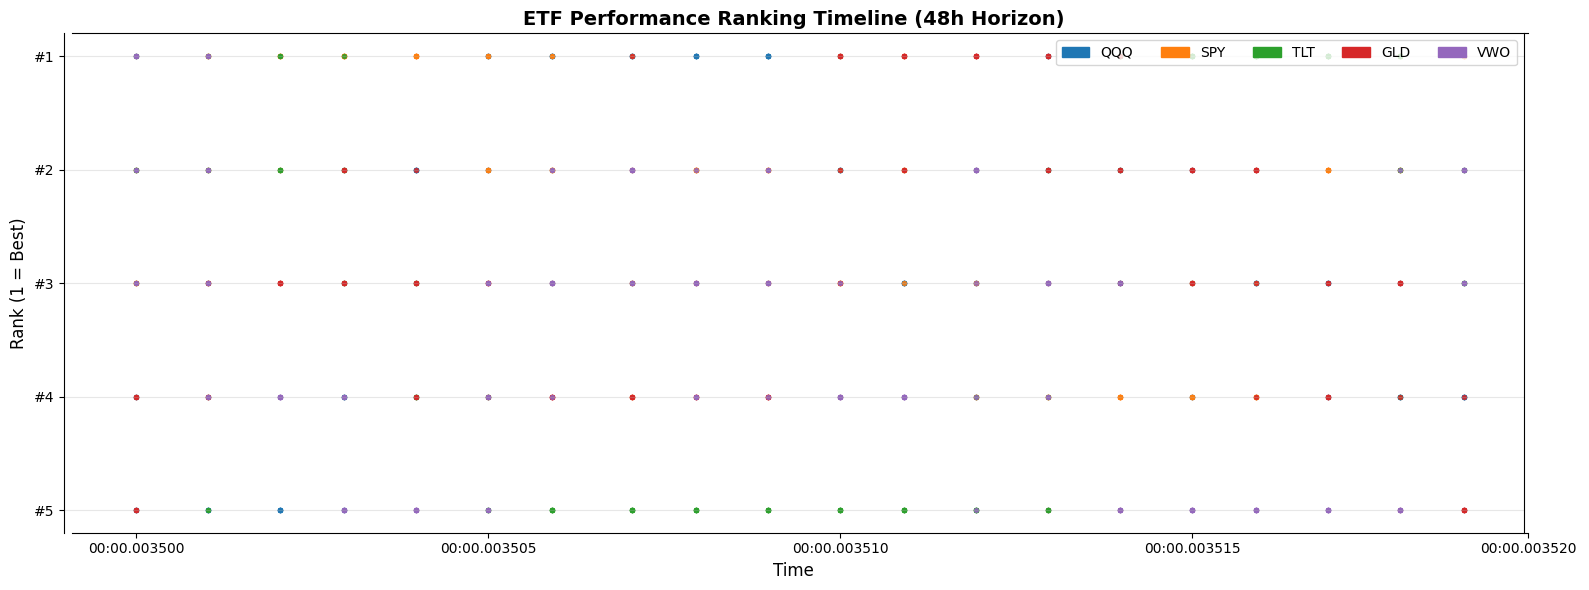

In [17]:
plot_performance_ranking_timeline(rolling_ranking[35000:35200], 48, p_show=True)

## Step 8: Persistence Analysis

Analyze which ETFs persist as top performers on hourly/daily patterns.

In [11]:
from strat.analysis import compute_weekly_performance_persistence

# Debug: Check input data
print(f'Input df shape: {df.shape}')
print(f'Index type: {type(df.index)}')
print(f'Index sample: {df.index[:3]}')

# Check close columns
#QQQ_S_close_f32

close_cols = [c for c in df.columns if 's_close_f32' in c.lower()]
print(f'Close columns found: {len(close_cols)}')
if close_cols:
    print(f'  Sample: {close_cols[:3]}')

# Check date range
if isinstance(df.index, pd.DatetimeIndex):
    date_range = df.index.max() - df.index.min()
    print(f'\nDate range: {date_range.days} days (~{date_range.days // 7} weeks)')
else:
    print(f'\nIndex range: {df.index.min()} to {df.index.max()}')

# Compute persistence (need at least 7 weeks for lookback=5, forward=1)
persistence_df = compute_weekly_performance_persistence(
    p_df=df,
    p_etf_list=ETF_LIST,
    p_lookback_weeks=5,
    p_forward_weeks=1,
)

print(f'\nPersistence DataFrame shape: {persistence_df.shape}')
if len(persistence_df) > 0:
    print(persistence_df.head())
else:
    print('Empty result - need at least 7 weeks of data')


Input df shape: (48107, 611)
Index type: <class 'pandas.RangeIndex'>
Index sample: RangeIndex(start=0, stop=3, step=1)
Close columns found: 5
  Sample: ['QQQ_S_close_f32', 'SPY_S_close_f32', 'TLT_S_close_f32']

Index range: 0 to 48106

Persistence DataFrame shape: (0, 0)
Empty result - need at least 7 weeks of data


In [19]:
from strat.analysis import analyze_performance_persistence

if len(persistence_df) > 0:
    persistence_stats = analyze_performance_persistence(
        p_persistence_df=persistence_df,
        p_etf_list=ETF_LIST,
    )

    print(f'Overall hit rates:')
    print(f"  1-week lookback: {persistence_stats['overall']['hit_rate_1w']:.1%}")
    print(f"  5-week lookback: {persistence_stats['overall']['hit_rate_Nw']:.1%}")

    print(f'\nHit rates by hour:')
    print(persistence_stats['by_hour'])

    print(f'\nHit rates by day of week:')
    print(persistence_stats['by_day'])

    print(f'\nPrediction frequency:')
    print(persistence_stats['prediction_frequency'])
else:
    print('No persistence data to analyze')


KeyError: 'hit_1w'